In [1]:
%pip install torch torchvision matplotlib scikit-learn seaborn -q

In [2]:
import torch
import torchvision
import matplotlib
import sklearn
import seaborn

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("matplotlib:", matplotlib.__version__)
print("sklearn:", sklearn.__version__)
print("seaborn:", seaborn.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
matplotlib: 3.10.0
sklearn: 1.6.1
seaborn: 0.13.2
Using device: cuda


In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2029, 0.1369, 0.1152])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2029, 0.1369, 0.1152])
])

print("Transforms ready!")

Transforms ready!


In [4]:
from torchvision import datasets

full_dataset = datasets.EuroSAT(root='./data', download=True)
print(f"Total images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 294MB/s]


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [5]:
train_dataset = datasets.EuroSAT(root='./data', transform=train_transform, download=False)
val_dataset   = datasets.EuroSAT(root='./data', transform=val_transform,   download=False)
test_dataset  = datasets.EuroSAT(root='./data', transform=val_transform,   download=False)

print("Datasets loaded with transforms!")

Datasets loaded with transforms!


In [6]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_set, _, _  = random_split(train_dataset, [train_size, val_size, test_size], generator=generator)

generator = torch.Generator().manual_seed(42)
_, val_set, _    = random_split(val_dataset,   [train_size, val_size, test_size], generator=generator)

generator = torch.Generator().manual_seed(42)
_, _, test_set   = random_split(test_dataset,  [train_size, val_size, test_size], generator=generator)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 18900 | Val: 4050 | Test: 4050


In [7]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2)

print("DataLoaders ready!")

DataLoaders ready!


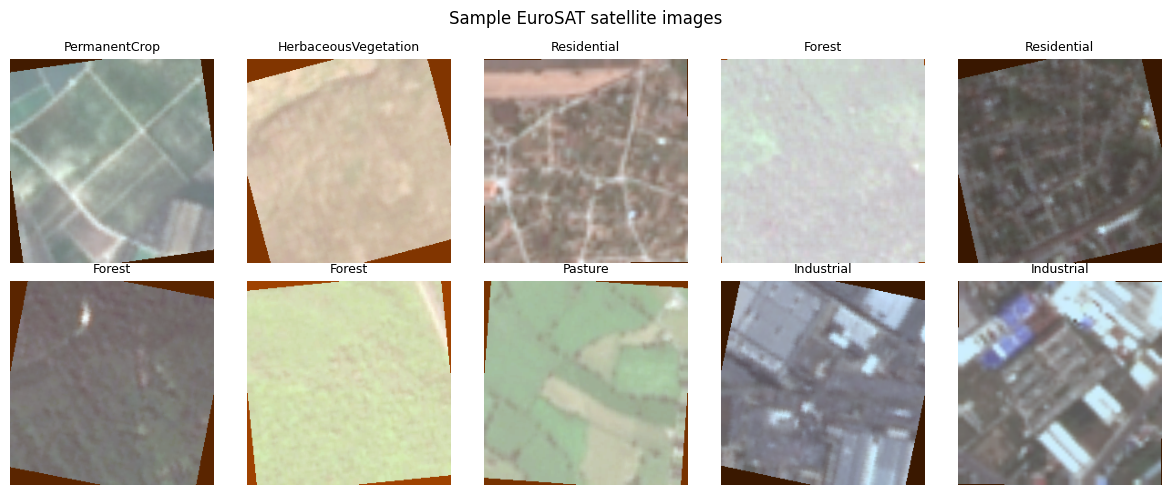

In [8]:
import matplotlib.pyplot as plt

class_names = full_dataset.classes
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')

plt.suptitle("Sample EuroSAT satellite images")
plt.tight_layout()
plt.show()

In [9]:
import torch.nn as nn
from torchvision import models

# Load ResNet18 pretrained on ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze ALL layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer with our head (10 satellite classes)
in_features = resnet.fc.in_features  # 512
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

model = resnet.to(device)
print(model.fc)
print(f"\nTotal params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)

Total params:     11,310,410
Trainable params: 133,898


In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Phase 1 ready — training head only!")

Phase 1 ready — training head only!


In [11]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

print("Functions ready!")

Functions ready!


In [12]:
EPOCHS = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = eval_epoch(model, val_loader)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

torch.save(model.state_dict(), "satellite_resnet18_phase1.pth")
print("Phase 1 model saved!")

Epoch 01/15 | Train Loss: 0.7186 Acc: 0.7646 | Val Loss: 0.4697 Acc: 0.8425
Epoch 02/15 | Train Loss: 0.4384 Acc: 0.8485 | Val Loss: 0.3419 Acc: 0.8830
Epoch 03/15 | Train Loss: 0.3944 Acc: 0.8652 | Val Loss: 0.3005 Acc: 0.8993
Epoch 04/15 | Train Loss: 0.3721 Acc: 0.8703 | Val Loss: 0.3073 Acc: 0.8894
Epoch 05/15 | Train Loss: 0.3519 Acc: 0.8786 | Val Loss: 0.3055 Acc: 0.8896
Epoch 06/15 | Train Loss: 0.3181 Acc: 0.8913 | Val Loss: 0.2713 Acc: 0.9072
Epoch 07/15 | Train Loss: 0.3173 Acc: 0.8897 | Val Loss: 0.2694 Acc: 0.9094
Epoch 08/15 | Train Loss: 0.3072 Acc: 0.8933 | Val Loss: 0.2594 Acc: 0.9128
Epoch 09/15 | Train Loss: 0.2914 Acc: 0.9014 | Val Loss: 0.2508 Acc: 0.9128
Epoch 10/15 | Train Loss: 0.2973 Acc: 0.8975 | Val Loss: 0.2565 Acc: 0.9111
Epoch 11/15 | Train Loss: 0.2742 Acc: 0.9020 | Val Loss: 0.2351 Acc: 0.9183
Epoch 12/15 | Train Loss: 0.2698 Acc: 0.9070 | Val Loss: 0.2450 Acc: 0.9170
Epoch 13/15 | Train Loss: 0.2684 Acc: 0.9072 | Val Loss: 0.2206 Acc: 0.9230
Epoch 14/15 

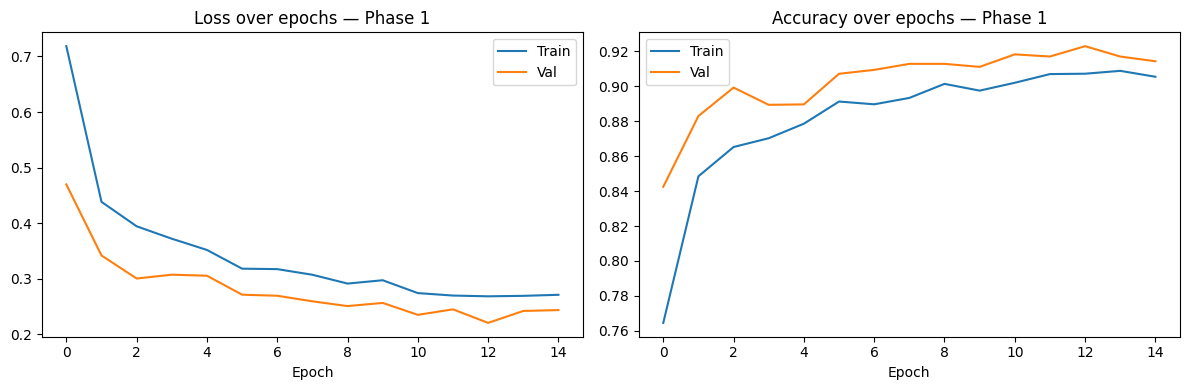

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Val')
ax1.set_title('Loss over epochs — Phase 1')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy over epochs — Phase 1')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
# Phase 2 — Unfreeze last block for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001  # 10x smaller!
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print("Phase 2 ready — fine-tuning layer4!")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Phase 2 ready — fine-tuning layer4!
Trainable params: 8,527,626


In [15]:
EPOCHS = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = eval_epoch(model, val_loader)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

torch.save(model.state_dict(), "satellite_resnet18_phase2.pth")
print("Phase 2 model saved!")

Epoch 01/10 | Train Loss: 0.2207 Acc: 0.9278 | Val Loss: 0.1142 Acc: 0.9578
Epoch 02/10 | Train Loss: 0.1452 Acc: 0.9518 | Val Loss: 0.0981 Acc: 0.9669
Epoch 03/10 | Train Loss: 0.1202 Acc: 0.9589 | Val Loss: 0.1070 Acc: 0.9662
Epoch 04/10 | Train Loss: 0.0886 Acc: 0.9706 | Val Loss: 0.1036 Acc: 0.9667
Epoch 05/10 | Train Loss: 0.0792 Acc: 0.9720 | Val Loss: 0.0805 Acc: 0.9733
Epoch 06/10 | Train Loss: 0.0785 Acc: 0.9742 | Val Loss: 0.0838 Acc: 0.9721
Epoch 07/10 | Train Loss: 0.0637 Acc: 0.9779 | Val Loss: 0.0763 Acc: 0.9731
Epoch 08/10 | Train Loss: 0.0599 Acc: 0.9798 | Val Loss: 0.0766 Acc: 0.9748
Epoch 09/10 | Train Loss: 0.0626 Acc: 0.9795 | Val Loss: 0.0762 Acc: 0.9743
Epoch 10/10 | Train Loss: 0.0508 Acc: 0.9830 | Val Loss: 0.0718 Acc: 0.9765
Phase 2 model saved!


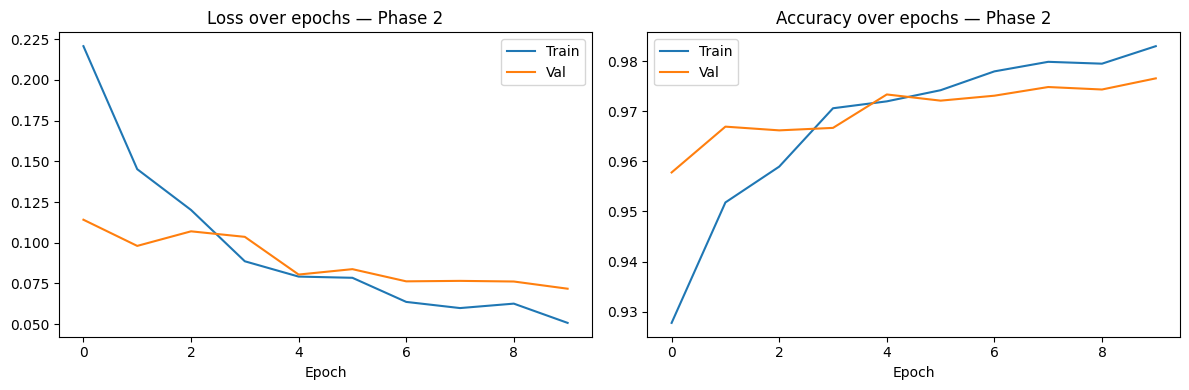

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Val')
ax1.set_title('Loss over epochs — Phase 2')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy over epochs — Phase 2')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
import torch
import torch.nn as nn
from torchvision import models

resnet = models.resnet18(weights=None)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet.load_state_dict(torch.load(
    'satellite_resnet18_phase2.pth',
    map_location=device
))
model = resnet.to(device)
model.eval()

print("Model loaded! Ready to predict!")

Model loaded! Ready to predict!


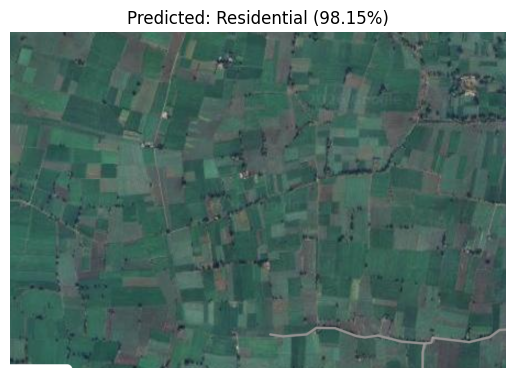


All class probabilities:
AnnualCrop                 0.00%  
Forest                     0.01%  
HerbaceousVegetation       0.00%  
Highway                    0.00%  
Industrial                 0.00%  
Pasture                    0.00%  
PermanentCrop              1.83%  
Residential               98.15%  █████████████████████████████████████████████████
River                      0.00%  
SeaLake                    0.00%  


In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names
class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
               'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
               'River', 'SeaLake']

# Load model
resnet = models.resnet18(weights=None)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)
resnet.load_state_dict(torch.load(
    'satellite_resnet18_phase2.pth',
    map_location=device
))
model = resnet.to(device)
model.eval()

# Transform
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3444, 0.3803, 0.4078],
                         std=[0.2029, 0.1369, 0.1152])
])

# ---- Change filename below to test different images ----
img = Image.open('test_image.png').convert('RGB')
# --------------------------------------------------------

img_tensor = test_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)[0]
    prediction = output.argmax(1)
    confidence = probs.max().item()

# Show image + prediction
plt.imshow(img)
plt.title(f"Predicted: {class_names[prediction]} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

# Show all class probabilities
print("\nAll class probabilities:")
for i, name in enumerate(class_names):
    bar = '█' * int(probs[i].item() * 50)
    print(f"{name:<25} {probs[i].item()*100:5.2f}%  {bar}")